In [1]:
import data_preparation
import models
import hydra 
from hydra import compose, initialize
import logging 
import torch 
import matplotlib.pyplot as plt 

In [2]:
initialize(version_base=None, config_path="../config")
cfg = compose(config_name="train_general.yaml", overrides=['dataset=climsim_from_npy', 'model=sparse_unet', 'target_group=JJA'])
print(cfg.dataset)
print(cfg.model)


{'dataset_name': 'climsim_from_npy', 'input_dim': 94, 'output_dim': 98, 'levels': 45, 'normalize': True, 'target_group': '${target_group}', 'data_dir': '/work/scratch-pw5/bradlesc/climsim/processed/group_by_months/', 'input_file': 'input.npy', 'target_file': 'target.npy', 'output_scale_file_path': '/home/users/bradlesc/projects/ClimSim/preprocessing/normalizations/outputs/output_scale.nc', 'v1_targets': ['ptend_t', 'ptend_q0001', 'cam_out_NETSW', 'cam_out_FLWDS', 'cam_out_PRECSC', 'cam_out_PRECC', 'cam_out_SOLS', 'cam_out_SOLL', 'cam_out_SOLSD', 'cam_out_SOLLD'], 'split': {'train': 0.8, 'val': 0.1, 'test': 0.1}, 'dataset_testing_sample_rates': {'quick': 10000, 'reduced': 100, 'full': 7}, 'group_method': 'group_by_months', 'group_by_months': {'num_groups': 4, 'target_group': '${target_group}', 'groups': {'DJF': [], 'MAM': [], 'JJA': [], 'SON': []}, 'test_group': {'SON': []}, 'val_group': {'SON': []}}, 'general_dataset_config': {'num_workers': '${testing.num_workers}', 'persistent_worker

# P2.1.4.1: Cracking open the unet
https://www.notion.so/P2-1-4-1-Cracking-open-climsim_unet-2c5634ce8d1280e4868fd37ee1c50e96?source=copy_link

Note book aimed to develop method for looking at attention patterns within the climsim_unet

## Task 1: Standard run
We will work with in distribution for now and see how this performs (i.e model trained on SON and tested on SON). Perhaps later we can see how the behaviour changes for the shifted examples

In [3]:
# path_to_model = '/home/users/bradlesc/projects/ClimSim/logs/p2.1.3/11/unet_from_npy_multiseed_2025-12-10-09-35-41/climsim_unet_group_SON/climsim_unet_0_2025-12-10-09-35-41.ckpt'
path_to_model = '/home/users/bradlesc/projects/ClimSim/logs/p2.1.4/2/testing/functional_test/2025-12-14-10-43-27/sparse_unet_group_JJA_log_lambda_-5.254_lambda_update_0.0009943_target_loss_0.006508/sparse_unet_0_2025-12-14-10-43-27.ckpt'

In [5]:
# Model
model = models.load_model_from_checkpoint(path_to_model, cfg.model.name, cfg.model.single_run_configuration, cfg.dataset)

# Get normalization stats
trainset = data_preparation.ClimSimNpyDataset(cfg.dataset, cfg.testing.dataset_testing_type, None, None, None)
normalisation_stats = trainset.normalisation_stats
# Data 
dataset = data_preparation.ClimSimNpyDataset(cfg.dataset, cfg.testing.dataset_testing_type, None, normalisation_stats, cfg.model.name)
dataloader = data_preparation.get_dataloader(cfg.dataset, None, cfg.testing.dataset_testing_type , 50, dataset)

# Predictions
with torch.no_grad():
    for batch in dataloader:
        inputs, targets = batch
        outputs, _, _ = model(inputs)
        print('Batch processed')
        break

print(f'Inputs shape: {inputs.shape}')
print(f'Targets shape: {targets.shape}')
print(f'Outputs shape: {outputs.shape}')

Batch processed
Inputs shape: torch.Size([50, 6, 48])
Targets shape: torch.Size([50, 98])
Outputs shape: torch.Size([50, 98])


## Task 2: Extract the information
so small changes have been made to climsim unet2 to extract attention weights and make sure they are the same values as the current method. To which it passed...

In [7]:
attention_block = model.model.mid[0]
# att_weight = attention_block.att_weight
att_weight = attention_block.sparse_att_weights
print(att_weight.shape)

torch.Size([50, 6, 6])


In [8]:
print(att_weight[1])
print(att_weight[2])

tensor([[0.0000, 0.0000, 0.1699, 0.0000, 0.0000, 0.0000],
        [0.1885, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1742, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.1695, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1774, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.1397, 0.0000]])
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.1529, 0.0000],
        [0.0000, 0.0000, 0.1787, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1849, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2160, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2013, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.1478, 0.0000, 0.0000]])


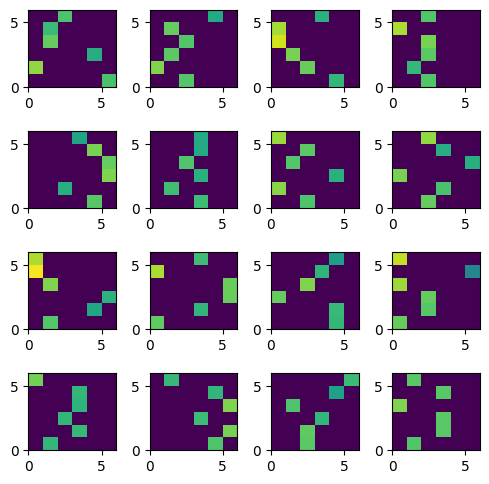

In [9]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(5,5))

vmax = att_weight.max().item()
vmin = att_weight.min().item()

for i, ax in enumerate(axes.flatten()):
    im = ax.pcolormesh(att_weight[i].cpu().numpy(), cmap='viridis', vmin=vmin, vmax=vmax, shading='auto')

plt.tight_layout()
plt.show()

Ok lets get some things clear here
1. We start with 45+3 layers to our data
2. We reduce this to 24 then 12 then 6 
3. And end up with a B, 6, 6 attention matrix 

Cool nice 

1. Two of our variables are height dependant 
2. Whilst the others are repeated for all heights 
3. Therefore to it would theoretically be possible to attend to any of the levels to get this information.
4. But as the 1d convolution is done between channels, it may mix these together so that at each level there is some 'level specific flux'? 

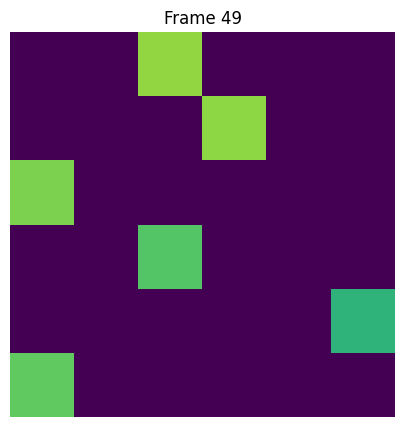

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# att_weight: torch.Tensor of shape (N, H, W)
# Example: att_weight = torch.rand(16, 32, 32)
# Use your actual att_weight tensor here.
N = att_weight.shape[0]
vmax = att_weight.max().item()
vmin = att_weight.min().item()

fig, ax = plt.subplots(figsize=(5,5))
# initialize with the first frame
im = ax.imshow(att_weight[0].cpu().numpy(), cmap='viridis', vmin=vmin, vmax=vmax, origin='lower', interpolation='nearest')
ax.set_title("Frame 0")
plt.axis('off')  # optional

def update(frame):
    data = att_weight[frame].cpu().numpy()
    im.set_array(data)
    ax.set_title(f"Frame {frame}")
    return (im,)

anim = FuncAnimation(fig, update, frames=N, interval=300, blit=True)  # interval in ms

# Display in notebook
HTML(anim.to_jshtml())
